In [1]:
%pip install catppuccin

In [2]:
import tensorflow as tf
import catppuccin
import keras
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])

In [3]:
NUM_WORDS = 10000
INPUT_DIM = 100
OUTPUT_DIM = 128
BATCH_SIZE = 32
EPOCHS = 5

In [4]:
from keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NUM_WORDS)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [5]:
from keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=INPUT_DIM, padding='post')
X_test = pad_sequences(X_test, maxlen=INPUT_DIM,padding='post')

X = np.concat((X_train, X_test), axis=0)
y = np.concat((y_train,y_test), axis=0)
X.shape, y.shape

((50000, 100), (50000,))

In [6]:
from keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
model_vanilla = keras.Sequential([
    Input(shape=(INPUT_DIM,)),
    Embedding(input_dim=NUM_WORDS, output_dim=OUTPUT_DIM, mask_zero=True),
    SimpleRNN(64, return_sequences=True, kernel_regularizer='l2'),
    SimpleRNN(64, kernel_regularizer='l2'),
    Dropout(0.35),
    Dense(1,activation='sigmoid'),
],name='vanilla')
model_vanilla.summary()

Model: "vanilla"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,300,673 (4.96 MB)

 Trainable params: 1,300,673 (4.96 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_vanilla.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['acc'])
history_vanilla = model_vanilla.fit(X,y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - acc: 0.6452 - loss: 0.7814 - val_acc: 0.8327 - val_loss: 0.4038
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - acc: 0.8292 - loss: 0.4132 - val_acc: 0.8504 - val_loss: 0.3603
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - acc: 0.8650 - loss: 0.3510 - val_acc: 0.8477 - val_loss: 0.3792
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - acc: 0.8782 - loss: 0.3314 - val_acc: 0.8379 - val_loss: 0.3956
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - acc: 0.8914 - loss: 0.2952 - val_acc: 0.8246 - val_loss: 0.4252


In [8]:
from keras.layers import LSTM
model_lstm = keras.Sequential([
    Input(shape=(INPUT_DIM,)),
    Embedding(input_dim=NUM_WORDS, output_dim=OUTPUT_DIM, mask_zero=True),
    LSTM(64, return_sequences=True, kernel_regularizer='l2'),
    LSTM(64, kernel_regularizer='l2'),
    Dropout(0.35),
    Dense(1,activation='sigmoid'),
],name='lstm')
model_lstm.summary()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model_lstm.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['acc'])
history_lstm = model_lstm.fit(X,y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - acc: 0.8034 - loss: 0.5213 - val_acc: 0.8540 - val_loss: 0.3557
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - acc: 0.8763 - loss: 0.3240 - val_acc: 0.8376 - val_loss: 0.3730
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.8895 - loss: 0.2950 - val_acc: 0.8458 - val_loss: 0.3672
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.8998 - loss: 0.2717 - val_acc: 0.8544 - val_loss: 0.3444
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9070 - loss: 0.2545 - val_acc: 0.8537 - val_loss: 0.3429


In [10]:
from keras.layers import GRU
model_gru = keras.Sequential([
    Input(shape=(INPUT_DIM,)),
    Embedding(input_dim=NUM_WORDS, output_dim=OUTPUT_DIM, mask_zero=True),
    GRU(64, return_sequences=True, kernel_regularizer='l2'),
    GRU(64, kernel_regularizer='l2'),
    Dropout(0.35),
    Dense(1,activation='sigmoid'),
],name='gru')
model_gru.summary()

Model: "gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_gru.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['acc'])
history_gru = model_gru.fit(X,y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - acc: 0.7984 - loss: 0.5193 - val_acc: 0.8537 - val_loss: 0.3565
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - acc: 0.8788 - loss: 0.3134 - val_acc: 0.8622 - val_loss: 0.3249
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.8974 - loss: 0.2747 - val_acc: 0.8639 - val_loss: 0.3274
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.9126 - loss: 0.2433 - val_acc: 0.8649 - val_loss: 0.3276
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - acc: 0.9269 - loss: 0.2121 - val_acc: 0.8611 - val_loss: 0.3661


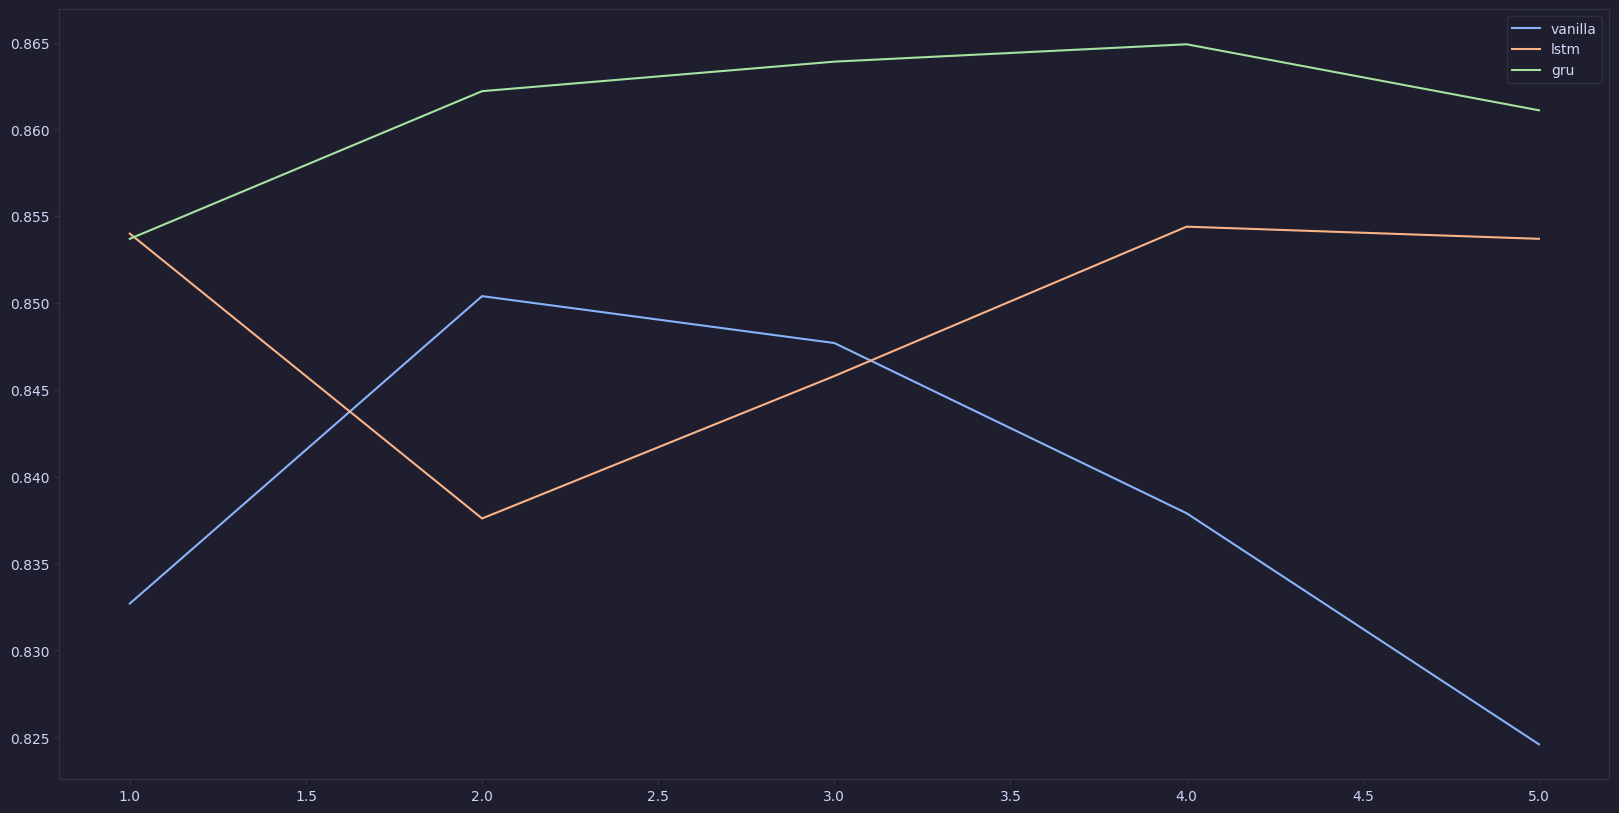

In [12]:
import numpy as np
x= np.arange(1,EPOCHS+1)

acc_vanilla = history_vanilla.history['val_acc']
acc_lstm = history_lstm.history['val_acc']
acc_gru = history_gru.history['val_acc']
plt.figure(figsize=(20,10))
plt.plot(x, acc_vanilla, label='vanilla')
plt.plot(x, acc_lstm, label='lstm')
plt.plot(x, acc_gru, label='gru')
plt.legend()
plt.show()